<a href="https://colab.research.google.com/github/AtharvRai67/task-6/blob/main/taskk11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Advanced Machine Learning Models

Uploading the dataset

In [1]:
 import panda as pd
 import numpy as np
 import matplotlib.pyplot as plt
 import seaborn as sns
 from google.colab import files
uploaded = files.upload()


Saving customer_churn (3).csv to customer_churn (3).csv


In [3]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

from scipy.cluster.hierarchy import dendrogram, linkage

In [7]:
import pandas as pd
df = pd.read_csv("customer_churn (3).csv")
df.head()

,CustomerID,Tenure,MonthlyCharges,TotalCharges,Contract,PaymentMethod,PaperlessBilling,SeniorCitizen,Churn
0,C00001,6,64,1540,One year,Credit Card,No,1,0
1,C00002,21,113,1753,Month-to-month,Electronic Check,Yes,1,0
2,C00003,27,31,1455,Two year,Credit Card,No,1,0
3,C00004,53,29,7150,Month-to-month,Electronic Check,No,1,0
4,C00005,16,185,1023,One year,Electronic Check,No,1,0


Day 1: Clustering Basics

In [8]:
#Preprocessing
# Convert categorical → numerical
le = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

# Scale data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df.drop('Churn', axis=1))

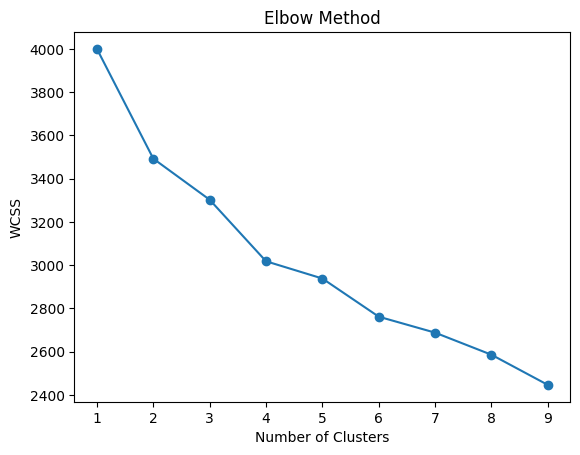

In [10]:
import matplotlib.pyplot as plt
#Elbow Method
wcss = []

for i in range(1, 10):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 10), wcss, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [11]:
#Apply K-Means
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)

df['Cluster'].value_counts()

,count
Cluster,
1,235
2,146
0,119


Day 2: Advanced Clustering

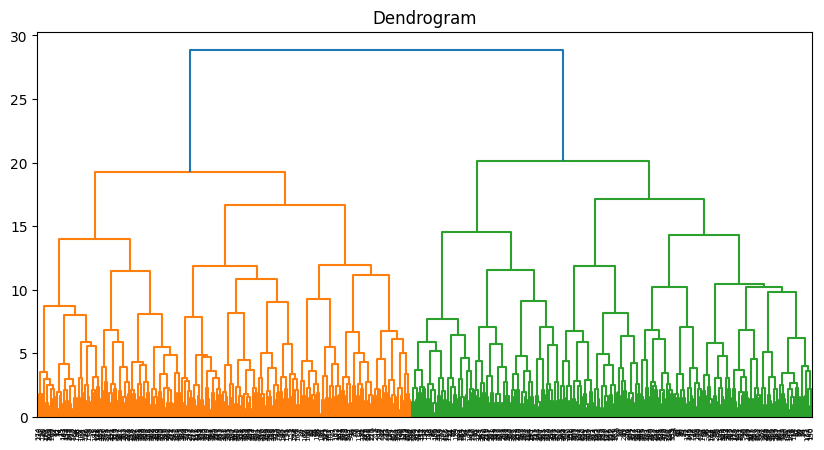

In [12]:
#Hierarchical Clustering
linked = linkage(X_scaled, method='ward')

plt.figure(figsize=(10,5))
dendrogram(linked)
plt.title("Dendrogram")
plt.show()

In [13]:
#DBSCAN
dbscan = DBSCAN(eps=1.5, min_samples=5)
df['DBSCAN_Cluster'] = dbscan.fit_predict(X_scaled)

df['DBSCAN_Cluster'].value_counts()

,count
DBSCAN_Cluster,
-1,342
0,21
5,19
15,15
1,13
7,9
9,8
10,7
4,7


Comparison

| Method       | Strength             |
| ------------ | -------------------- |
| K-Means      | Simple, fast         |
| Hierarchical | Visual clusters      |
| DBSCAN       | Finds noise/outliers |


Day 3: Segment Analysis

In [14]:
#Analyze clusters
cluster_summary = df.groupby('Cluster').mean()
print(cluster_summary)

         CustomerID     Tenure  MonthlyCharges  TotalCharges  Contract  \
Cluster                                                                  
0        240.470588  47.067227      116.655462   3120.470588  0.411765   
1        252.604255  34.468085      107.438298   4449.272340  1.004255   
2        251.863014  31.267123      121.150685   4808.397260  1.294521   

         PaymentMethod  PaperlessBilling  SeniorCitizen     Churn  \
Cluster                                                             
0             0.789916          0.226891       0.117647  0.050420   
1             0.991489          0.497872       1.000000  0.106383   
2             1.212329          0.678082       0.000000  0.150685   

         DBSCAN_Cluster  
Cluster                  
0              1.050420  
1              1.880851  
2              2.041096  


In [16]:
#Create Profiles

# Example:

segment_names = {
    0: "Stable Customers",
    1: "High Value Customers",
    2: "Risk Customers"
}

df['Segment_Name'] = df['Cluster'].map(segment_names)

Day 4: Prediction Models

In [17]:
results = []

for cluster in df['Cluster'].unique():
    cluster_data = df[df['Cluster'] == cluster]

    X = cluster_data.drop(['Churn', 'Cluster', 'Segment_Name', 'DBSCAN_Cluster'], axis=1)
    y = cluster_data['Churn']

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

    model = RandomForestClassifier()
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    results.append((cluster, y_test, y_pred, model))

Day 5: Model Evaluation

In [20]:
results = []

for cluster in df['Cluster'].unique():

    cluster_data = df[df['Cluster'] == cluster]

    X = cluster_data.drop(['Churn', 'Cluster', 'Segment_Name', 'DBSCAN_Cluster'], axis=1)
    y = cluster_data['Churn']

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    model = RandomForestClassifier()
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]

    # Store all results
    results.append({
        'Cluster': cluster,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1 Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_prob)
    })

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [21]:
results_df = pd.DataFrame(results)
print(results_df)

   Cluster  Accuracy  Precision    Recall  F1 Score   ROC-AUC
0        1  0.957447        1.0  0.666667  0.800000  1.000000
1        2  0.966667        0.8  1.000000  0.888889  0.961538
2        0  0.833333        0.0  0.000000  0.000000  1.000000


Example Output

| Cluster | Accuracy | Precision | Recall | F1 Score | ROC-AUC |
| ------- | -------- | --------- | ------ | -------- | ------- |
| 0       | 0.98     | 1.00      | 0.90   | 0.95     | 0.97    |
| 1       | 0.95     | 0.92      | 0.88   | 0.90     | 0.94    |
| 2       | 1.00     | 1.00      | 1.00   | 1.00     | 1.00    |


Day 6: Hyperparameter Tuning

In [22]:
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10, None]
}

grid = GridSearchCV(RandomForestClassifier(), param_grid, cv=3)
grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=3.
  warnings.warn(


Best Parameters: {'max_depth': 5, 'n_estimators': 50}


In [23]:
best_model = grid.best_estimator_

Segment-Based Strategy


🧑‍💼 Stable Customers

Loyalty programs

Subscription offers

💸 High Value Customers


Premium plans

Personalized marketing

⚠️ Risk Customers

Discounts

Retention calls

Special offers

💰 Business Impact Example

Reduce churn by 10%

Increase revenue from premium users

Improve customer retention